In [19]:
from typing import TypedDict
from langgraph.graph import StateGraph

In [20]:
class AgentState(TypedDict):
    name: str
    age: int
    skill: list[str]
    result: str

In [21]:
def name_node(state: AgentState) -> AgentState:
    state["result"] = f"{state['name']}, welcome to the system!"
    return state

def age_node(state: AgentState) -> AgentState:
    state["result"] = f"{state['result']} You are {state['age']} years old!"
    return state

def skills_node(state: AgentState) -> AgentState:
    state["result"] = f"{state['result']} Your have skills in: {', '.join(state['skill'])}"
    return state

In [22]:
graph = StateGraph(AgentState)

graph.add_node("name_node", name_node)
graph.add_node("age_node", age_node)
graph.add_node("skills_node", skills_node)

graph.set_entry_point("name_node")
graph.add_edge("name_node", "age_node")
graph.add_edge("age_node", "skills_node")
graph.set_finish_point("skills_node")
app = graph.compile()

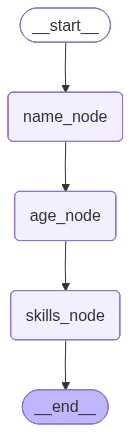

In [23]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [24]:
inputs = {
    "name": "Linda",
    "age": 31,
    "skill": ["Python", "Machine Learning", "LangGraph"]
}
output = app.invoke(inputs)
print(output["result"])

Linda, welcome to the system! You are 31 years old! Your have skills in: Python, Machine Learning, LangGraph
